### Testing policy masking with ordered tuples


In [32]:
# Set up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(parent_dir)
print('Working directory set to:', parent_dir)

Working directory set to: /local0/rossin


In [33]:
# Import general packages
from openpyxl import Workbook, load_workbook
from datetime import datetime
import torch
from matplotlib import pyplot as plt
from pytorch_lightning.loggers import CometLogger
import numpy as np
from itertools import product
from tqdm import tqdm

# Import Agent-Environment packages
from RL4CRN.environments.environment import Environment
from RL4CRN.environments.parallel_environments import ParallelEnvironments
from RL4CRN.environments.serial_environments import SerialEnvironments
from RL4CRN.agents.reinforce_agent import REINFORCEAgent
from RL4CRN.policies.add_reaction_by_ordered_index import AddReactionByOrderedIndex

# Import Interface packages
from RL4CRN.env2agent_interface.explicit_observer import ExplicitObserver
from RL4CRN.env2agent_interface.explicit_tensorizer import ExplicitTensorizer
from RL4CRN.agent2env_interface.library_actuator import LibraryActuator
from RL4CRN.agent2env_interface.iocrn_stepper import IOCRNStepper

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.iocrns.reaction_library import construct_mass_action_library

# Import Reward packages
from RL4CRN.rewards.deterministic import dynamic_tracking_error

In [34]:
logger = None

In [35]:
# Construct the template CRN
# decradation of X_1, Z_1 and Z_2 (fixed rate, dilution)
deg1 = MassAction(reactant_labels=['X_1'], product_labels=[], params=[0.1], params_controllability=[False])
deg2 = MassAction(reactant_labels=['Z_1'], product_labels=[], params=[0.1], params_controllability=[False])
deg3 = MassAction(reactant_labels=['Z_2'], product_labels=[], params=[0.1], params_controllability=[False])
# input reaction (X_1 induction)
inductionX1 = MassAction(reactant_labels=[], product_labels=['X_1'], input_channels=['u_1'], params=[1.], params_controllability=[True])

crn_template = IOCRN([deg1, deg2, deg3, inductionX1], output_labels=['X_1'])
crn_template.compile()
p = crn_template.num_inputs # Number of inputs of the IOCRNs
print("Template CRN:")
print(crn_template)

# Construct the library of possible reactions
species_labels = ['X_1', 'Z_1', 'Z_2']
library = construct_mass_action_library(species_labels=species_labels, order=1)
crn_template.set_library_context(library)
M = len(library.reactions) # Number of possible reactions
K = library.get_num_parameters() # Total number of parameters in all the reactions of the library
print("Library of possible reactions:")
print(library)
print("------------------------------------------------")

Template CRN:
Inputs: ['u_1'] 
Species: ['X_1', 'Z_1', 'Z_2'] 
Output Species: ['X_1'] 
X_1 ----> ∅;  [MAK(0.1)]
Z_1 ----> ∅;  [MAK(0.1)]
Z_2 ----> ∅;  [MAK(0.1)]
∅ ----> X_1;  [MAK(1.0, u_1)]
Library of possible reactions:
Number of reactions: 13
R0: ∅ ----> ∅;  [MAK(None)]
R1: ∅ ----> X_1;  [MAK(None)]
R2: ∅ ----> Z_1;  [MAK(None)]
R3: ∅ ----> Z_2;  [MAK(None)]
R4: X_1 ----> ∅;  [MAK(None)]
R5: X_1 ----> Z_1;  [MAK(None)]
R6: X_1 ----> Z_2;  [MAK(None)]
R7: Z_1 ----> ∅;  [MAK(None)]
R8: Z_1 ----> X_1;  [MAK(None)]
R9: Z_1 ----> Z_2;  [MAK(None)]
R10: Z_2 ----> ∅;  [MAK(None)]
R11: Z_2 ----> X_1;  [MAK(None)]
R12: Z_2 ----> Z_1;  [MAK(None)]
------------------------------------------------


In [36]:
# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'Number of CPUs available: {os.cpu_count()}') 

Using device: cuda
Number of CPUs available: 128


In [ ]:
# Hyperparameters
max_added_reactions = 5                             # Maximum number of reactions
N_CPUs = 1                             # Number of CPUs          
N = 1                                       # Number of samples (batch size)    
width = 1024                                        # Width of the neural networks  
depth = 5                                           # Depth of the neural networks 
deep_layer_size = 1024*10                           # Size of the deep layer encoding the CRNs
allow_input_influence = False                       # Allow input influence in the policy
learning_rate = 1e-2                                # Learning rate for the optimizer 
hall_of_fame_size = 10                              # Size of the hall of fame  
entropy_scheduler = {                               # Entropy scheduler parameters 
    'entropy_weight': 0.01, 
    'entropy_update_coefficient': 1, 
    'entropy_schedule': 1000, 
    'minimum_entropy_weight': 0.01
}
entropy_weights_per_head = {'structure': 1., 'continuous': 1., 'discrete': 0.0, 'input_influence': 0.0} 
risk_scheduler = {                                  # Risk scheduler parameters
    'risk': 0.95, 
    'risk_update': 0.0, 
    'max_risk': 1.0, 
    'risk_schedule': 1000
}
epoch_num = 300                                     # Number of epochs for training
render_schedule = 10                                 # Render every # of epochs
render_mode = {                                     # Mode of the experiment
    'style': 'logger', 
    'task': 'transients', 
    'format': 'image',
    'topology': True,
    'bounds': [50]
}
render_n_best = 1                                   # Number of best CRNs to plot responses for
render_disregard_percentage = 0.9                   # Percentage of worst CRNs to disregard in the responses plotting

# Parameter distribution for the reactions added by the agent
continuous_distribution = {"type": 'lognormal_1D'}

# Time horizon for the simulation
t_f = 100                                           # Final time for the simulation
N_t = 1000                                          # Number of time steps
time_horizon = np.linspace(0, t_f, N_t, dtype=np.float32)

# Construct the IOCRN inputs
u_list = [ np.array([1.]) ] # possible input values
# u_list = [np.array(u) for u in product(nums, repeat=p)] # list of input combinations, each input is a numpy array of shape (p,)

# Construct the IOCRN initial conditions
ic_list = [[0.0, 0.0, 0.0]]
ic = IC(names=species_labels, values=ic_list)

# Construct the weights for the performance metric
w = np.ones(N_t)
w = w[np.newaxis, :]

# print(u_list)
r_list = [np.array([1.]) for _ in u_list] * len(ic_list)

# Construct the compute reward routine
def compute_reward(state):
    # print(r_list)
    x0_list = ic.get_ic(state)
    return dynamic_tracking_error(state, u_list, x0_list, time_horizon, r_list, w, norm=1, LARGE_NUMBER=1e4)

In [38]:
# Construct parallel environments
crn_0 = crn_template.clone()
# mult_env = ParallelEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, N_CPUs=N_CPUs, logger=logger)
mult_env = SerialEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, logger=logger)

In [39]:
# Construct the policy
encoder_attributes = {"hidden_size": width, "num_layers": depth}
structure_head_attributes = {"hidden_size": width, "num_layers": depth}
rate_head_attributes = {"hidden_size": width, "num_layers": depth}
input_influence_head_attributes = {"hidden_size": width, "num_layers": depth}
masks = {"continuous": library.get_parameter_mask(mode="continuous"), "discrete": library.get_parameter_mask(mode="discrete"), "logit": library.get_logit_mask()}
policy = AddReactionByOrderedIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, target_set_size=crn_template.num_reactions+max_added_reactions, allow_input_influence=False, masks=masks, device=device, continuous_distribution=continuous_distribution, entropy_weights_per_head=entropy_weights_per_head,
                                   combinatorial_bias_enabled=True)
# Construct the agent
agent = REINFORCEAgent(policy, allow_input_influence=False, logger=logger, learning_rate=learning_rate, entropy_scheduler=entropy_scheduler, risk_scheduler=risk_scheduler, device=device)

In [40]:
# Construct the interfaces
observer = ExplicitObserver(reaction_library=library)
tensorizer = ExplicitTensorizer(device=device)
actuator = LibraryActuator(reaction_library=library)
stepper = IOCRNStepper()

In [41]:
# Training Loop   
epoch_num = 1000 
signatures = []

for i in tqdm(range(epoch_num)):
    # print(mult_env.envs[0].state.last_task_info)
    mult_env.reset()
    # print(mult_env.envs[0].state.last_task_info)
    for j in range(max_added_reactions):
        # print("OBS", torch.tensor(mult_env.envs[0].state.get_bool_signature()).float())
        observations = mult_env.observe(observer, tensorizer)
        actions = agent.act(observations, actuator)
        out = mult_env.step(actions, stepper)
        # plot mask evolution:
        # print("MSK", agent.policy.template_mask.cpu())
        # print("ACT", torch.tensor(mult_env.envs[0].state.get_bool_signature()).float() - 2*agent.policy.template_mask.cpu())
        signature = torch.tensor(mult_env.envs[0].state.get_bool_signature()).float() - 2*agent.policy.template_mask.cpu()
        signature = torch.cumsum(torch.clamp(signature, min=0), 1).argmax().item()
        # print("SIG", signature)
        signatures.append(signature)
        
    # print(mult_env.envs[0].state.last_task_info)
    rewards = mult_env.get_reward(compute_reward)
    # print(mult_env.envs[0].state.last_task_info)
    agent.update(rewards, step_iteration=i)

# print(signatures)


100%|██████████| 1000/1000 [00:43<00:00, 22.78it/s]


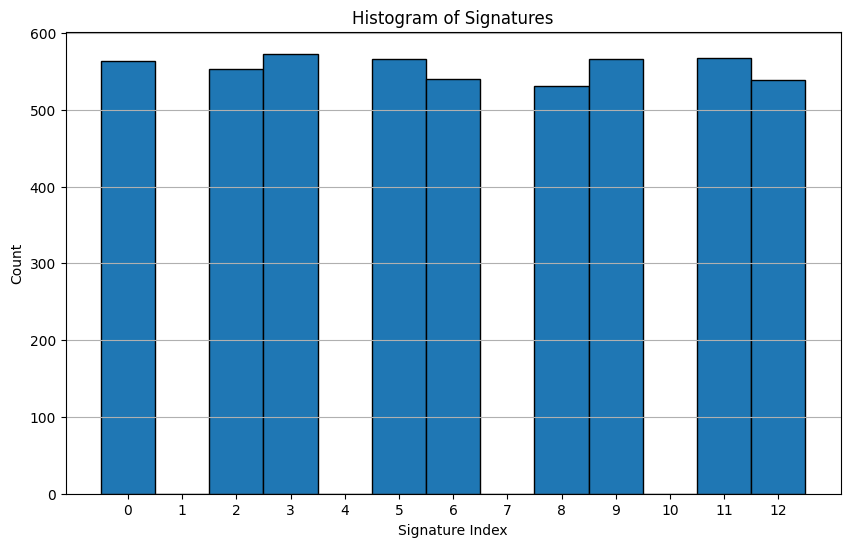

In [42]:
# compute counter of signatures
from collections import Counter
signature_counts = Counter(signatures)

# plot histogram of signatures
plt.figure(figsize=(10, 6))
plt.hist(signatures, bins=np.arange(-0.5, max(signatures)+1.5, 1), edgecolor='black')
plt.xlabel('Signature Index')
plt.ylabel('Count')
plt.title('Histogram of Signatures')
plt.xticks(range(max(signatures)+1))
plt.grid(axis='y')
plt.show()